In [ ]:
# 1. Install the latest Kaggle CLI client
!pip install --upgrade -q kaggle

# 2. Create the hidden .kaggle directory and save your specific access token
!mkdir -p ~/.kaggle
!echo "KGAT_e28b733576ab116600ea7d7523136ebb" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

# 3. Download UrbanSound8K directly to the cloud instance
!kaggle datasets download -d chrisfilo/urbansound8k

# 4. Unzip the downloaded file
import zipfile
import os

print("Unzipping files... this takes about 30 seconds.")
with zipfile.ZipFile("urbansound8k.zip", 'r') as zip_ref:
    zip_ref.extractall("./urbansound8k")
print("Done! Let's check the contents:")
print(os.listdir("./urbansound8k"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 5.7 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/chrisfilo/urbansound8k
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 5.61G/5.61G [01:15<00:00, 79.4MB/s]

Unzipping files... this takes about 30 seconds.
Done! Let's check the contents:
['fold2', 'fold9', 'fold7', 'fold5', 'fold4', 'fold6', 'fold3', 'fold10', 'UrbanSound8K.csv', 'fold8', 'fold1']


Metadata Sample:
      slice_file_name  fold             class
0    100032-3-0-0.wav     5          dog_bark
1  100263-2-0-117.wav     5  children_playing
2  100263-2-0-121.wav     5  children_playing
3  100263-2-0-126.wav     5  children_playing
4  100263-2-0-137.wav     5  children_playing

Loading sample file: ./urbansound8k/fold5/100032-3-0-0.wav (Class: dog_bark)


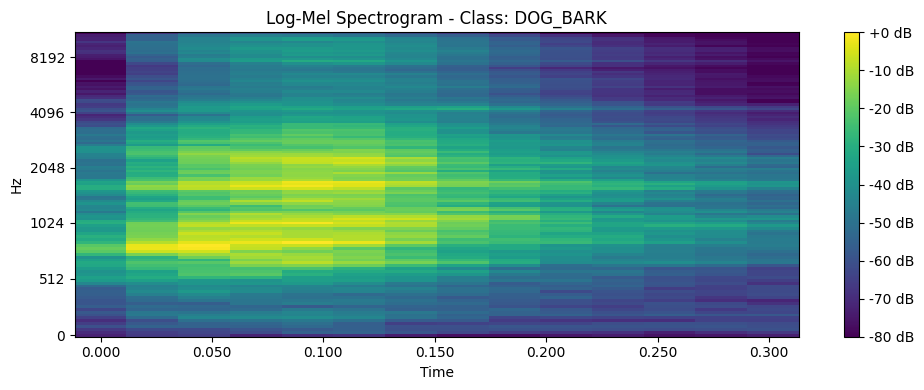

In [ ]:
import os
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the metadata CSV to find file paths and labels
csv_path = "./urbansound8k/UrbanSound8K.csv"
df = pd.read_csv(csv_path)

# Let's peek at the first few rows to verify it loaded
print("Metadata Sample:")
print(df[['slice_file_name', 'fold', 'class']].head())

# 2. Pick a specific row to visualize (e.g., index 0)
sample_row = df.iloc[0]
filename = sample_row['slice_file_name']
fold = sample_row['fold']
sound_class = sample_row['class']

# 3. Construct the exact path to the file inside the cloud instance
# Example target path: ./urbansound8k/fold1/100263-2-0-117.wav
audio_path = os.path.join("./urbansound8k", f"fold{fold}", filename)
print(f"\nLoading sample file: {audio_path} (Class: {sound_class})")

# 4. Load the audio signal
y, sr = librosa.load(audio_path, sr=22050)

# 5. Generate the Log-Mel Spectrogram
mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)

# 6. Plot the feature matrix
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spect_db, sr=sr, x_axis='time', y_axis='mel', cmap='viridis')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Log-Mel Spectrogram - Class: {sound_class.upper()}')
plt.tight_layout()
plt.show()